In [9]:
%matplotlib inline

In [1]:
import requests
import numpy as np
import streamlit as st
import re
import plotly.graph_objects as go
from IPython.display import display
import pandas as pd
import re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def get_all_chains(ticker):
    r = requests.get(
        f"https://cdn.cboe.com/api/global/delayed_quotes/options/{ticker}.json"
    )
    data = r.json()

    return data

In [ ]:
def parse_chain(data):
    options = data["data"]["options"]
    rows = []
    for o in options:
        # parse option string e.g. AAPL260413C00185000
        match = re.match(r"([A-Z]+)(\d{6})([CP])(\d{8})", o["option"])
        if not match:
            continue
        ticker, expiry, call_put, strike = match.groups()
        rows.append(
            {
                "expiry": f"20{expiry[:2]}-{expiry[2:4]}-{expiry[4:]}",
                "strike": int(strike) / 1000,
                "type": "call" if call_put == "C" else "put",
                "mid": (o["bid"] + o["ask"]) / 2,
                "iv": o["iv"],
                "delta": o["delta"],
                "gamma": o["gamma"],
                "theta": o["theta"],
                "vega": o["vega"],
                "volume": o["volume"],
                "oi": o["open_interest"],
                "bid": o["bid"],
                "ask": o["ask"],
                "last": o["last_trade_price"],
            }
        )
    return pd.DataFrame(rows)

In [3]:
data = get_all_chains("NVDA")
options = data["data"]["options"]
rows = []
for o in options:
    print(o)

{'option': 'NVDA260415C00100000', 'bid': 93.9, 'bid_size': 18.0, 'ask': 98.0, 'ask_size': 3.0, 'iv': 0.0, 'open_interest': 6.0, 'volume': 10.0, 'delta': 0.9999, 'gamma': 0.0, 'vega': 0.0, 'theta': 0.0, 'rho': 0.0015, 'theo': 96.4653, 'change': 6.785, 'open': 92.42, 'high': 95.28, 'low': 92.32, 'tick': 'up', 'last_trade_price': 95.06, 'last_trade_time': '2026-04-14T15:31:16', 'percent_change': 7.68621, 'prev_day_close': 95.3250007629394}
{'option': 'NVDA260415P00100000', 'bid': 0.0, 'bid_size': 0.0, 'ask': 0.01, 'ask_size': 96.0, 'iv': 3.9904, 'open_interest': 79.0, 'volume': 0.0, 'delta': -0.0001, 'gamma': 0.0, 'vega': 0.0, 'theta': -0.0009, 'rho': 0.0, 'theo': 0.0009, 'change': 0.0, 'open': 0.0, 'high': 0.0, 'low': 0.0, 'tick': 'no_change', 'last_trade_price': 0.01, 'last_trade_time': '2026-04-10T15:42:38', 'percent_change': 0.0, 'prev_day_close': 0.00499999988824129}
{'option': 'NVDA260415C00105000', 'bid': 88.9, 'bid_size': 7.0, 'ask': 91.9, 'ask_size': 1.0, 'iv': 0.0, 'open_interes

In [12]:
def filter_surface_df(ticker, df, S, strike_range=0.05, n_expiracies=10):

    df = df[
        (df["strike"] >= S * (1 - strike_range))
        & (df["strike"] <= S * (1 + strike_range))
    ]

    next_10 = sorted(df["expiry"].unique())

    next_10 = next_10[:n_expiracies] if n_expiracies <= len(next_10) else next_10

    df = df[df["expiry"].isin(next_10)]

    OTM_puts = df[(df["type"] == "put") & (df["strike"] < S)]
    OTM_calls = df[(df["type"] == "call") & (df["strike"] > S)]

    surface_df = pd.concat([OTM_puts, OTM_calls]).sort_values(["expiry", "strike"])
    surface_df = surface_df[["expiry", "strike", "iv"]]

    return surface_df

In [13]:
data = get_all_chains("AAPL")
df = parse_chain(data)
surface_df = filter_surface_df("AAPL", df, 260)

In [14]:
def surface_vol_builder(surface_df):

    surface_df["days"] = (
        pd.to_datetime(surface_df["expiry"]) - pd.Timestamp.today()
    ).dt.days

    pivot = surface_df.pivot_table(index="expiry", columns="strike", values="iv")

    fig = go.Figure(
        data=[
            go.Surface(
                x=pivot.columns.values,  # strikes
                y=pivot.index.values,  # days
                z=pivot.values,  # IV matrix
                colorscale="Viridis",
            )
        ]
    )

    fig.update_layout(
        title="Volatility Surface",
        scene=dict(
            xaxis_title="Strike", yaxis_title="Days to Expiry", zaxis_title="IV"
        ),
        template="plotly_dark",
    )

    return fig

In [ ]:
def other_surface_builder(surface_df):

    plt.ion()
    fig = plt.figure(figsize=(16, 9))
    fig.canvas.manager.set_window_title("volatility Surface")
    fig.patch.set_facecolor("#0b0d0f")

    ax_3d = plt.subplot2grid((1, 3), (0, 0), colspan=2, projection="3d")
    ax_skew = plt.subplot2grid((1, 3), (0, 2))

    pivot = (
        surface_df.pivot_table(index="expiry", columns="strike", values="iv")
        .sort_index()
        .sort_index(axis=1)
    )
    pivot = pivot.interpolate(method="linear", axis=0).bfill().ffill()

    X, Y_idx = np.meshgrid(pivot.columns, np.arange(len(pivot.index)))
    Z = pivot.values

    curr_elev, curr_azim = ax_3d.elev, ax_3d.azim

    ax_3d.clear()
    ax_3d.set_facecolor("#0b0d0f")
    ax_3d.plot_surface(X, Y_idx, Z, cmap="magma", edgecolor="white", lw=0.1, alpha=0.9)

    ax_3d.set_yticks(np.arange(len(pivot.index)))
    ax_3d.set_yticklabels(pivot.index)
    ax_3d.set_title("Volatility model", color="white")
    ax_3d.view_init(elev=curr_elev, azim=curr_azim)

    return ax_3d

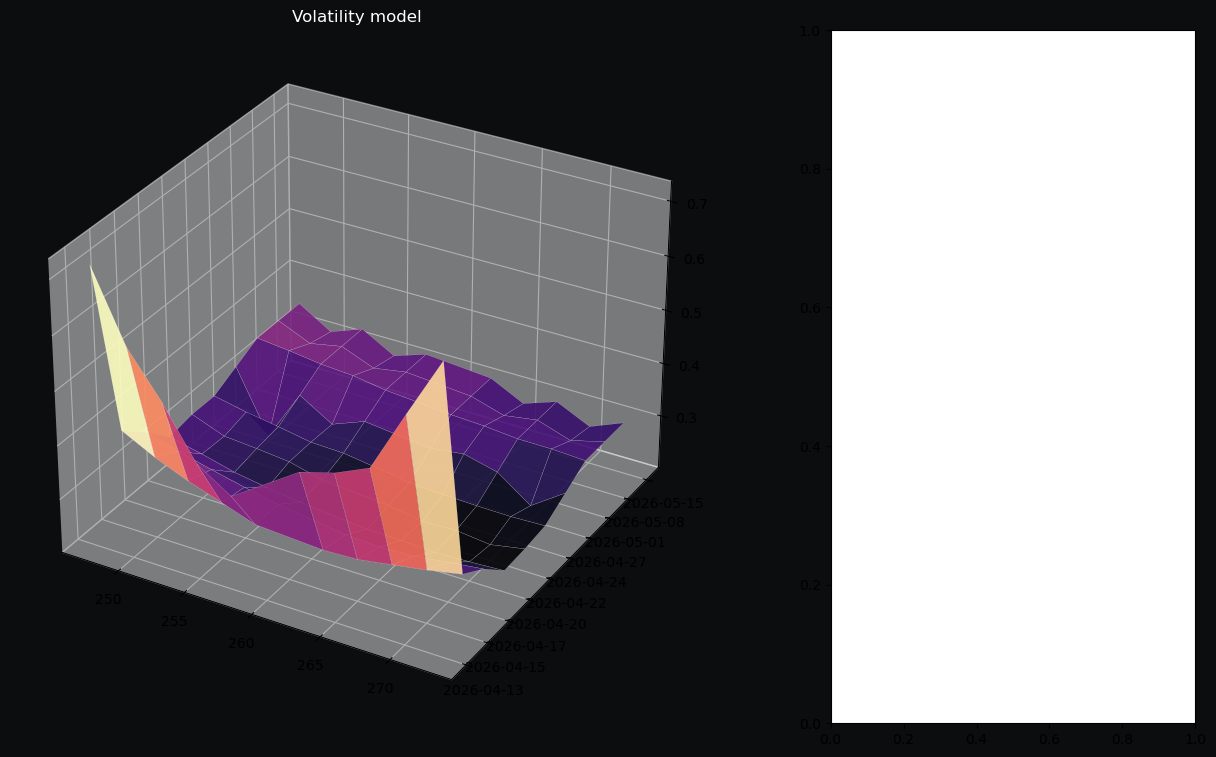

In [36]:
other_surface_builder(surface_df)

In [20]:
fig = surface_vol_builder(surface_df)
display(fig)

In [21]:
def smile_vol(df):
    next_1 = sorted(df["expiry"].unique())[:1]
    df = df[df["expiry"].isin(next_1)]

    smile = df[["strike", "iv"]].reset_index(drop=True)

    fig, ax = plt.subplots()
    ax.plot(smile["strike"], smile["iv"])
    ax.set_xlabel("Strike")
    ax.set_ylabel("IV")
    ax.set_title(f"Vol Smile — {next_1[0]}")

    return fig

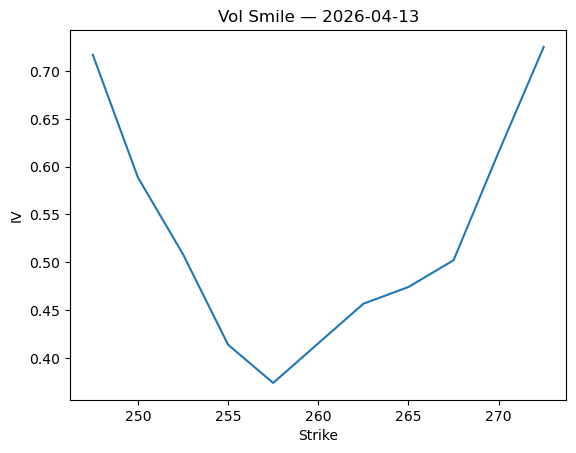

In [22]:
fig = smile_vol(surface_df)